In [ ]:
!nvidia-smi

Wed Apr 29 14:59:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import shutil
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix
)

from scipy.stats import pearsonr

# ---- Fix existing mountpoint contents ----
mount_path = "/content/drive"

# If folder exists and has files, remove it first
if os.path.exists(mount_path):
    try:
        shutil.rmtree(mount_path)
    except:
        pass

# Recreate clean folder
os.makedirs(mount_path, exist_ok=True)

# ---- Mount Google Drive ----
from google.colab import drive
drive.mount(mount_path)

# ---- Save dir ----
SAVE_DIR = "/content/drive/MyDrive/REFUGE2_RESULTS"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Drive mounted successfully.")
print("Imports complete.")

Mounted at /content/drive
Drive mounted successfully.
Imports complete.


In [ ]:
TRUE_PATH = f"{SAVE_DIR}/kfold_all_y_true.npy"
PRED_PATH = f"{SAVE_DIR}/kfold_all_y_pred.npy"

for label, path in [("y_true", TRUE_PATH), ("y_pred", PRED_PATH)]:
    status = "✓" if os.path.exists(path) else "✗ MISSING — run NB10 first"
    print(f"  {status}  {label}: {path}")

y_true = np.load(TRUE_PATH)
y_pred = np.load(PRED_PATH)
n      = len(y_true)

print(f"\nLoaded {n} samples from NB10 k-fold experiment")
print(f"True CDR  : min={y_true.min():.3f}  max={y_true.max():.3f}  "
      f"mean={y_true.mean():.3f}  std={y_true.std():.3f}")
print(f"Pred CDR  : min={y_pred.min():.3f}  max={y_pred.max():.3f}  "
      f"mean={y_pred.mean():.3f}  std={y_pred.std():.3f}")
print(f"\nThese are Drishti-GS clinical CDR values (0.31–0.95)")
print(f"Model: Hybrid ResNet50+ViT | 5-fold cross-validation")


  ✓  y_true: /content/drive/MyDrive/REFUGE2_RESULTS/kfold_all_y_true.npy
  ✓  y_pred: /content/drive/MyDrive/REFUGE2_RESULTS/kfold_all_y_pred.npy

Loaded 50 samples from NB10 k-fold experiment
True CDR  : min=0.310  max=0.950  mean=0.707  std=0.183
Pred CDR  : min=0.369  max=0.919  mean=0.691  std=0.132

These are Drishti-GS clinical CDR values (0.31–0.95)
Model: Hybrid ResNet50+ViT | 5-fold cross-validation


In [ ]:
mae    = mean_absolute_error(y_true, y_pred)
rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
r2     = r2_score(y_true, y_pred)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - 2)
pr, _  = pearsonr(y_true, y_pred)

# Fisher z-transform CI
z    = np.arctanh(pr)
se   = 1.0 / np.sqrt(n - 3)
ci_lo = float(np.tanh(z - 1.96 * se))
ci_hi = float(np.tanh(z + 1.96 * se))

print(f"\n{'─'*55}")
print(f"  Regression Metrics (confirming NB10 results)")
print(f"{'─'*55}")
print(f"  MAE          : {mae:.4f}")
print(f"  RMSE         : {rmse:.4f}")
print(f"  R²           : {r2:.4f}")
print(f"  Adjusted R²  : {adj_r2:.4f}")
print(f"  Pearson r    : {pr:.4f}  [95% CI: {ci_lo:.3f}, {ci_hi:.3f}]")
print(f"{'─'*55}")



───────────────────────────────────────────────────────
  Regression Metrics (confirming NB10 results)
───────────────────────────────────────────────────────
  MAE          : 0.1067
  RMSE         : 0.1364
  R²           : 0.4425
  Adjusted R²  : 0.4308
  Pearson r    : 0.6727  [95% CI: 0.485, 0.801]
───────────────────────────────────────────────────────


In [ ]:
def get_severity(cdr):
    """
    Clinical CDR severity thresholds.
    Based on established ophthalmological guidelines:
      Normal   : CDR < 0.50  (no glaucomatous cupping)
      Mild     : 0.50 ≤ CDR < 0.65  (borderline, requires monitoring)
      Moderate : 0.65 ≤ CDR < 0.80  (likely glaucoma, treatment advised)
      Severe   : CDR ≥ 0.80  (advanced glaucoma, urgent referral)
    """
    if cdr < 0.50:
        return "Normal"
    elif cdr < 0.65:
        return "Mild"
    elif cdr < 0.80:
        return "Moderate"
    else:
        return "Severe"

# Apply to true and predicted CDR
true_sev = [get_severity(c) for c in y_true]
pred_sev = [get_severity(c) for c in y_pred]

sev_df = pd.DataFrame({
    "True CDR":        y_true,
    "Predicted CDR":   y_pred,
    "True Severity":   true_sev,
    "Pred Severity":   pred_sev
})

print("Severity mapping applied.")
print(f"\nSample (first 10 rows):")
print(sev_df.head(10).to_string(index=False))


Severity mapping applied.

Sample (first 10 rows):
 True CDR  Predicted CDR True Severity Pred Severity
     0.46       0.436068        Normal        Normal
     0.36       0.406744        Normal        Normal
     0.74       0.836210      Moderate        Severe
     0.84       0.725156        Severe      Moderate
     0.82       0.784202        Severe      Moderate
     0.77       0.729289      Moderate      Moderate
     0.78       0.748216      Moderate      Moderate
     0.88       0.655593        Severe      Moderate
     0.92       0.886190        Severe        Severe
     0.84       0.659079        Severe      Moderate


In [ ]:
CATEGORIES = ["Normal", "Mild", "Moderate", "Severe"]

true_counts = {c: true_sev.count(c) for c in CATEGORIES}
pred_counts = {c: pred_sev.count(c) for c in CATEGORIES}

print(f"\n{'═'*58}")
print(f"  SEVERITY DISTRIBUTION TABLE")
print(f"  Dataset: Drishti-GS | n={n} | Model: Hybrid ResNet50+ViT")
print(f"{'═'*58}")
print(f"  {'Severity':<12} {'True Count':>12} {'Pred Count':>12} {'True %':>8} {'Pred %':>8}")
print(f"  {'─'*54}")
for cat in CATEGORIES:
    tc = true_counts[cat]
    pc = pred_counts[cat]
    tp = tc / n * 100
    pp = pc / n * 100
    print(f"  {cat:<12} {tc:>12} {pc:>12} {tp:>7.1f}% {pp:>7.1f}%")
print(f"  {'─'*54}")
print(f"  {'Total':<12} {n:>12} {n:>12} {'100.0%':>8} {'100.0%':>8}")
print(f"{'═'*58}")



══════════════════════════════════════════════════════════
  SEVERITY DISTRIBUTION TABLE
  Dataset: Drishti-GS | n=50 | Model: Hybrid ResNet50+ViT
══════════════════════════════════════════════════════════
  Severity       True Count   Pred Count   True %   Pred %
  ──────────────────────────────────────────────────────
  Normal                 10            4    20.0%     8.0%
  Mild                    5           12    10.0%    24.0%
  Moderate               16           24    32.0%    48.0%
  Severe                 19           10    38.0%    20.0%
  ──────────────────────────────────────────────────────
  Total                  50           50   100.0%   100.0%
══════════════════════════════════════════════════════════


In [ ]:
ct = pd.crosstab(
    pd.Categorical(true_sev, categories=CATEGORIES),
    pd.Categorical(pred_sev, categories=CATEGORIES),
    rownames=["True"],
    colnames=["Predicted"]
)

print(f"\n  SEVERITY CROSSTAB (True rows × Predicted columns):")
print(f"  {ct.to_string()}")

# Severity accuracy
correct   = sum(t == p for t, p in zip(true_sev, pred_sev))
sev_acc   = correct / n * 100

# Within-1-category accuracy (clinically useful — adjacent category errors are acceptable)
def is_within_one(t, p, cats=CATEGORIES):
    ti = cats.index(t)
    pi = cats.index(p)
    return abs(ti - pi) <= 1

within_one = sum(is_within_one(t, p) for t, p in zip(true_sev, pred_sev))
within_one_pct = within_one / n * 100

print(f"\n  Exact severity match   : {correct}/{n} = {sev_acc:.1f}%")
print(f"  Within-1-category match: {within_one}/{n} = {within_one_pct:.1f}%")
print(f"  (Within-1-category = clinically acceptable accuracy)")



  SEVERITY CROSSTAB (True rows × Predicted columns):
  Predicted  Normal  Mild  Moderate  Severe
True                                     
Normal          3     5         2       0
Mild            1     2         1       1
Moderate        0     4         9       3
Severe          0     1        12       6

  Exact severity match   : 20/50 = 40.0%
  Within-1-category match: 46/50 = 92.0%
  (Within-1-category = clinically acceptable accuracy)


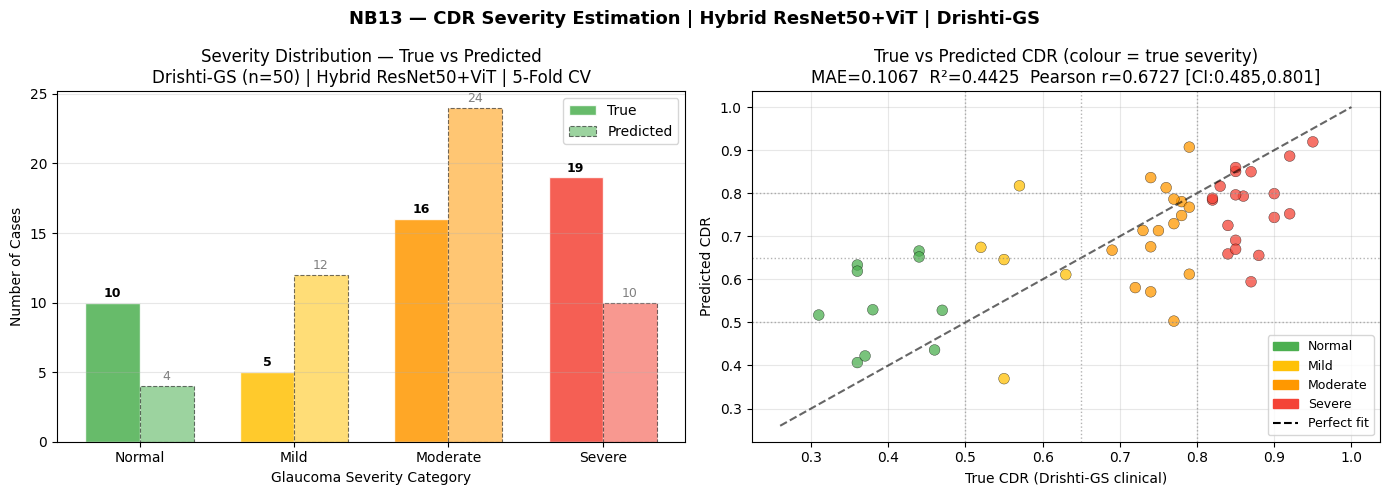

Figure saved: nb13_severity_analysis.png


In [ ]:
colors = {
    "Normal":   "#4CAF50",   # green
    "Mild":     "#FFC107",   # amber
    "Moderate": "#FF9800",   # orange
    "Severe":   "#F44336"    # red
}

x   = np.arange(len(CATEGORIES))
w   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — True vs Predicted distribution
bars_true = axes[0].bar(
    x - w/2,
    [true_counts[c] for c in CATEGORIES],
    w, label="True", alpha=0.85,
    color=[colors[c] for c in CATEGORIES], edgecolor="white"
)
bars_pred = axes[0].bar(
    x + w/2,
    [pred_counts[c] for c in CATEGORIES],
    w, label="Predicted", alpha=0.55,
    color=[colors[c] for c in CATEGORIES], edgecolor="black",
    linewidth=0.8, linestyle="--"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(CATEGORIES)
axes[0].set_xlabel("Glaucoma Severity Category")
axes[0].set_ylabel("Number of Cases")
axes[0].set_title(
    f"Severity Distribution — True vs Predicted\n"
    f"Drishti-GS (n={n}) | Hybrid ResNet50+ViT | 5-Fold CV"
)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Annotate bar counts
for bar in bars_true:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )
for bar in bars_pred:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        str(int(bar.get_height())),
        ha="center", va="bottom", fontsize=9, color="gray"
    )

# Scatter plot — True vs Predicted CDR with severity color coding
scatter_colors = [colors[get_severity(c)] for c in y_true]
sc = axes[1].scatter(y_true, y_pred, c=scatter_colors,
                     alpha=0.75, s=60, edgecolors="black", linewidths=0.3)
lims = [min(y_true.min(), y_pred.min()) - 0.05,
        max(y_true.max(), y_pred.max()) + 0.05]
axes[1].plot(lims, lims, 'k--', lw=1.5, label="Perfect fit", alpha=0.6)

# Add vertical threshold lines
for thresh, label_t in [(0.50, "0.50"), (0.65, "0.65"), (0.80, "0.80")]:
    axes[1].axvline(thresh, color="gray", linestyle=":", alpha=0.6,
                    linewidth=1)
    axes[1].axhline(thresh, color="gray", linestyle=":", alpha=0.6,
                    linewidth=1)

# Legend patches
patches = [mpatches.Patch(color=colors[c], label=c) for c in CATEGORIES]
axes[1].legend(handles=patches + [
    plt.Line2D([0], [0], color='k', linestyle='--', label="Perfect fit")
], fontsize=9)

axes[1].set_xlabel("True CDR (Drishti-GS clinical)")
axes[1].set_ylabel("Predicted CDR")
axes[1].set_title(
    f"True vs Predicted CDR (colour = true severity)\n"
    f"MAE={mae:.4f}  R²={r2:.4f}  Pearson r={pr:.4f} "
    f"[CI:{ci_lo:.3f},{ci_hi:.3f}]"
)
axes[1].grid(True, alpha=0.3)

plt.suptitle(
    "NB13 — CDR Severity Estimation | Hybrid ResNet50+ViT | Drishti-GS",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/nb13_severity_analysis.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved: nb13_severity_analysis.png")


In [ ]:
results_nb13 = {
    "experiment":      "NB13 — CDR Severity Classification",
    "model":           "Hybrid ResNet50+ViT",
    "dataset":         "Drishti-GS",
    "protocol":        "5-fold cross-validation (from NB10 Path B)",
    "n":               int(n),
    "regression_metrics": {
        "MAE":      round(float(mae),    4),
        "RMSE":     round(float(rmse),   4),
        "R2":       round(float(r2),     4),
        "Adj_R2":   round(float(adj_r2), 4),
        "Pearson":  round(float(pr),     4),
        "CI_95_lo": round(float(ci_lo),  4),
        "CI_95_hi": round(float(ci_hi),  4),
    },
    "severity_distribution": {
        "true":      {c: int(true_counts[c]) for c in CATEGORIES},
        "predicted": {c: int(pred_counts[c]) for c in CATEGORIES}
    },
    "severity_accuracy": {
        "exact_match_pct":      round(float(sev_acc),       2),
        "within_one_cat_pct":   round(float(within_one_pct), 2),
        "exact_correct":        int(correct),
        "within_one_correct":   int(within_one)
    },
    "severity_thresholds": {
        "Normal":   "CDR < 0.50",
        "Mild":     "0.50 ≤ CDR < 0.65",
        "Moderate": "0.65 ≤ CDR < 0.80",
        "Severe":   "CDR ≥ 0.80"
    },
    "paper_note": (
        f"CDR regression: Pearson r={pr:.4f} [95% CI: {ci_lo:.3f}–{ci_hi:.3f}]. "
        f"Severity exact match: {sev_acc:.1f}%. "
        f"Within-1-category: {within_one_pct:.1f}%. "
        "Use k-fold aggregate as Table 2 regression row. "
        "Use severity distribution as Table 3 or Figure 7."
    )
}

with open(f"{SAVE_DIR}/nb13_severity_results.json", "w") as f:
    json.dump(results_nb13, f, indent=2)

sev_df.to_csv(f"{SAVE_DIR}/nb13_severity_predictions.csv", index=False)

print(f"Saved: {SAVE_DIR}/nb13_severity_results.json")
print(f"Saved: {SAVE_DIR}/nb13_severity_predictions.csv")
print(f"Saved: {SAVE_DIR}/nb13_severity_analysis.png")


Saved: /content/drive/MyDrive/REFUGE2_RESULTS/nb13_severity_results.json
Saved: /content/drive/MyDrive/REFUGE2_RESULTS/nb13_severity_predictions.csv
Saved: /content/drive/MyDrive/REFUGE2_RESULTS/nb13_severity_analysis.png


In [ ]:
print(f"\n{'═'*60}")
print(f"  NB13 — PAPER-READY OUTPUT SUMMARY")
print(f"{'═'*60}")
print(f"\n  MODEL    : Hybrid ResNet50+ViT")
print(f"  DATASET  : Drishti-GS (n={n}, 5-fold CV)")
print(f"  PROTOCOL : 5-fold cross-validation")
print(f"\n  TABLE 2 — CDR REGRESSION ROW:")
print(f"  {'─'*50}")
print(f"  MAE      = {mae:.4f}")
print(f"  RMSE     = {rmse:.4f}")
print(f"  R²       = {r2:.4f}")
print(f"  Pearson r = {pr:.4f} [95% CI: {ci_lo:.3f}–{ci_hi:.3f}]")
print(f"\n  TABLE 3 / FIGURE 7 — SEVERITY DISTRIBUTION:")
print(f"  {'─'*50}")
print(f"  {'Category':<12} {'True':>8} {'Pred':>8}")
for cat in CATEGORIES:
    print(f"  {cat:<12} {true_counts[cat]:>8} {pred_counts[cat]:>8}")
print(f"\n  Severity exact match   : {sev_acc:.1f}%")
print(f"  Within-1-category match: {within_one_pct:.1f}%")
print(f"\n  FIGURE : nb13_severity_analysis.png")
print(f"    Left panel  = severity bar chart")
print(f"    Right panel = CDR scatter plot colour-coded by severity")
print(f"{'═'*60}")



════════════════════════════════════════════════════════════
  NB13 — PAPER-READY OUTPUT SUMMARY
════════════════════════════════════════════════════════════

  MODEL    : Hybrid ResNet50+ViT
  DATASET  : Drishti-GS (n=50, 5-fold CV)
  PROTOCOL : 5-fold cross-validation

  TABLE 2 — CDR REGRESSION ROW:
  ──────────────────────────────────────────────────
  MAE      = 0.1067
  RMSE     = 0.1364
  R²       = 0.4425
  Pearson r = 0.6727 [95% CI: 0.485–0.801]

  TABLE 3 / FIGURE 7 — SEVERITY DISTRIBUTION:
  ──────────────────────────────────────────────────
  Category         True     Pred
  Normal             10        4
  Mild                5       12
  Moderate           16       24
  Severe             19       10

  Severity exact match   : 40.0%
  Within-1-category match: 92.0%

  FIGURE : nb13_severity_analysis.png
    Left panel  = severity bar chart
    Right panel = CDR scatter plot colour-coded by severity
════════════════════════════════════════════════════════════
